In [1]:
import warnings
import logging

root_logger = logging.getLogger()
root_logger.setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

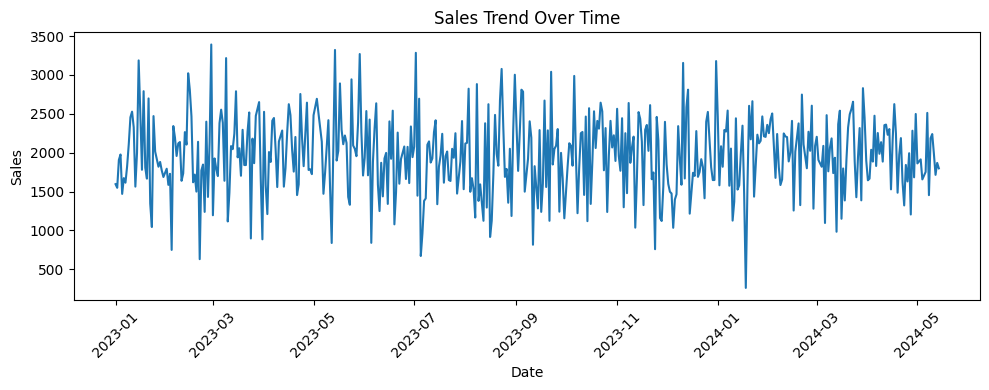

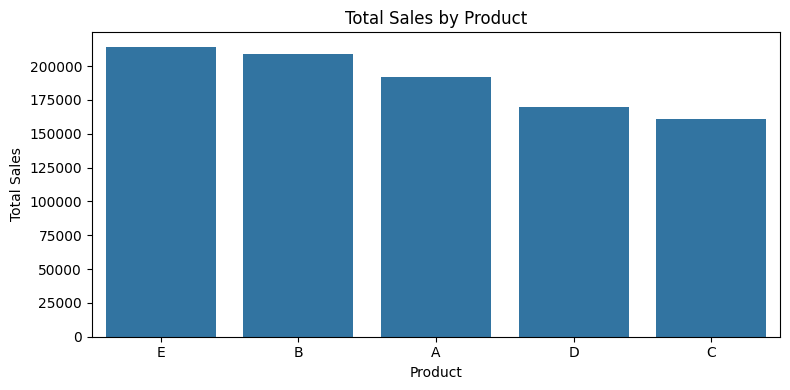

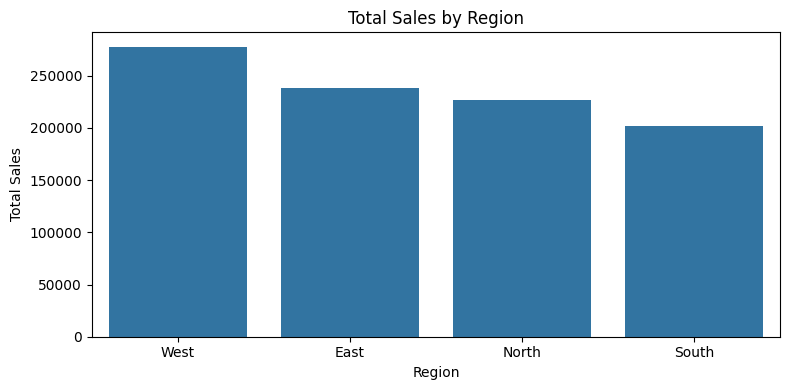

Summary Statistics:
                        Date Region Product        Sales  Units_Sold  Rep
count                   500    500     500   480.000000  480.000000  500
unique                  NaN      4       5          NaN         NaN    5
top                     NaN   West       E          NaN         NaN  Bob
freq                    NaN    148     114          NaN         NaN  104
mean    2023-09-07 12:00:00    NaN     NaN  1969.775354   20.162500  NaN
min     2023-01-01 00:00:00    NaN     NaN   259.600000    8.000000  NaN
25%     2023-05-05 18:00:00    NaN     NaN  1643.002500   17.000000  NaN
50%     2023-09-07 12:00:00    NaN     NaN  1975.610000   20.000000  NaN
75%     2024-01-10 06:00:00    NaN     NaN  2305.167500   23.000000  NaN
max     2024-05-14 00:00:00    NaN     NaN  3391.890000   33.000000  NaN
std                     NaN    NaN     NaN   498.995915    4.586748  NaN

Missing Values:
 Date           0
Region         0
Product        0
Sales         20
Units_Sold    20


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate a sample organizational sales dataset
np.random.seed(42)
n = 500
data = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], size=n),
    'Product': np.random.choice(['A', 'B', 'C', 'D', 'E'], size=n),
    'Sales': np.random.normal(loc=2000, scale=500, size=n).round(2),
    'Units_Sold': np.random.poisson(lam=20, size=n),
    'Rep': np.random.choice(['John', 'Jane', 'Alice', 'Bob', 'Eve'], size=n)
})

# Introduce some missing values
for col in ['Sales', 'Units_Sold']:
    data.loc[np.random.choice(n, size=20, replace=False), col] = np.nan

# EDA: Summary statistics
summary = data.describe(include='all')

# Missing value analysis
missing = data.isnull().sum()

# Distinguish column types
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include='object').columns.tolist()

# Correlation analysis for numerical columns
corr = data[num_cols].corr()

# Visualizations
plt.figure(figsize=(10, 4))
sns.lineplot(x='Date', y='Sales', data=data)
plt.title('Sales Trend Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
top_products = data.groupby('Product')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=top_products.index, y=top_products.values)
plt.title('Total Sales by Product')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
region_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Total Sales by Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Display summary statistics, missing values, and correlation matrix
print("Summary Statistics:\n", summary)
print("\nMissing Values:\n", missing)
print("\nCorrelation Matrix:\n", corr)